# **Guía de Actividades Práctico-Experimentales Nro. 011**

---

## **1. Datos Generales**

| **Atributo** | **Descripción** |
| :--- | :--- |
| **Estudiantes** | Kiara Condoy, Héctor Guerrero, Javier Guarnizo, Ricardo Ochoa, Emily Salas |
| **Asignatura** | Teoría de la Distribución y Probabilidad |
| **Ciclo** | 2do “A” |
| **Unidad** | 1 |
| **Práctica Nro.** | 011 |
| **Título de la Práctica** | **Inferencia Estadística Multigrupo: Análisis de Varianza (ANOVA de 1 factor) y Pruebas Post-Hoc (Tukey)** |
| **Nombre del Docente** | Cristian Ramiro Narváez Guillén |
| **Fecha** | Lunes 20 de julio 2026 |

---



**Tarea 1: Análisis de Varianza (ANOVA de 1 factor)**
---

El ANOVA compara la varianza entre los grupos frente a la varianza dentro de los grupos.

1. H0: Todas las medias poblacionales son iguales.
2. H1: Al menos una media poblacional es diferente.

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import f_oneway
# Ejemplo: Tiempos de respuesta (ping) de 3 algoritmos
np.random.seed(42)
grupo_A = np.random.normal(loc=45.0, scale=5.0, size=30)
grupo_B = np.random.normal(loc=46.5, scale=4.8, size=30)
grupo_C = np.random.normal(loc=52.0, scale=5.5, size=30)
stat_f, p_val_f = f_oneway(grupo_A, grupo_B, grupo_C)
print(f"Estadístico F: {stat_f:.4f} | Valor-p: {p_val_f:.4e}")

Estadístico F: 22.6087 | Valor-p: 1.2389e-08


 # **Tarea 2: Hito del Proyecto - Segmentación Multigrupo**

1. Importe su dataset regional.


In [4]:
import pandas as pd
import numpy as np

# 1. Conexión a la nueva hoja del Spreadsheet
url = 'https://docs.google.com/spreadsheets/d/1E-rrTgcTIWS-UnuVf1ldKvhDkwT6uUgh/export?format=xlsx'

try:
    # Nombre exacto de la pestaña
    df = pd.read_excel(url, sheet_name='Subnational 1 tree cover loss')

    # Limpieza básica
    df = df.dropna(how='all').reset_index(drop=True)
    print("¡Conexión exitosa a la hoja de Provincias!")

except Exception as e:
    print(f"Error: {e}")

¡Conexión exitosa a la hoja de Provincias!


2. Identifique una variable categórica con al menos 3 niveles (ej. tipo de conexión, meses, sectores).


Variable identificada: **subnational1 (Provincias)**

Tipo de variable: Categórica nominal.

Número de niveles: 24 niveles (categorías únicas).

Descripción: Esta variable registra las divisiones político-administrativas regionales de Ecuador.

A lo largo del dataset, se listan las 24 provincias del país como categorías independientes para el análisis.

3. Ejecute f_oneway y redacte un dictamen técnico: ¿El ANOVA sugiere que
existen diferencias significativas entre los niveles? ¿Es necesario investigar
más a fondo?

In [13]:
import pandas as pd
from scipy.stats import f_oneway, shapiro, levene

# Lista de provincias y columna de interés
provinces_of_interest = ['Loja', 'Azuay', 'Cañar']
column_name = 'tc_loss_ha_2022'

# Estructuras para almacenar los datos filtrados
anova_groups = []
group_names = []

# Iteración eficiente para extraer y validar datos
for prov in provinces_of_interest:
    # Extraer datos descartando valores nulos
    data_prov = df[df['subnational1'] == prov][column_name].dropna()

    if len(data_prov) > 1:
        anova_groups.append(data_prov)
        group_names.append(prov)
    else:
        print(f"Advertencia: La provincia '{prov}' no contiene suficientes observaciones (> 1).")

# Evaluación y ejecución del ANOVA
if len(anova_groups) >= 2:
    # 1. Prueba de homocedasticidad (Prueba de Levene)
    stat_lev, p_val_lev = levene(*anova_groups)
    print(f"Prueba de Levene (Homogeneidad de varianzas): Estadístico = {stat_lev:.4f}, p-valor = {p_val_lev:.4f}")

    # 2. Ejecución del ANOVA de un factor
    stat_f_provinces, p_val_f_provinces = f_oneway(*anova_groups)

    print("\n--- RESULTADOS ANOVA ---")
    print(f"Provincias analizadas: {', '.join(group_names)}")
    print(f"Variable analizada: {column_name}")
    print(f"Estadístico F: {stat_f_provinces:.4f}")
    print(f"Valor-p: {p_val_f_provinces:.4e}")

    # Interpretación automática de significancia
    alpha = 0.05
    if p_val_f_provinces < alpha:
        print("\nConclusión: Se rechaza H0. Existen diferencias estadísticamente significativas en la pérdida de cobertura arbórea entre las provincias.")
    else:
        print("\nConclusión: No se rechaza H0. No existen diferencias estadísticamente significativas entre las provincias.")
else:
    print("Error: Se requieren al menos dos grupos válidos para realizar el ANOVA.")
    stat_f_provinces, p_val_f_provinces = float('nan'), float('nan')

Prueba de Levene (Homogeneidad de varianzas): Estadístico = 1.9822, p-valor = 0.1627

--- RESULTADOS ANOVA ---
Provincias analizadas: Loja, Azuay, Cañar
Variable analizada: tc_loss_ha_2022
Estadístico F: 69.3344
Valor-p: 5.6168e-10

Conclusión: Se rechaza H0. Existen diferencias estadísticamente significativas en la pérdida de cobertura arbórea entre las provincias.


# **Tarea 3: Pruebas Post-hoc (Tukey HSD)**

Si el ANOVA rechaza H0, debemos identificar qué pares difieren.

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     A      B   1.8592 0.3003 -1.1146  4.8329  False
     A      C   8.0116    0.0  5.0378 10.9854   True
     B      C   6.1524    0.0  3.1787  9.1262   True
----------------------------------------------------


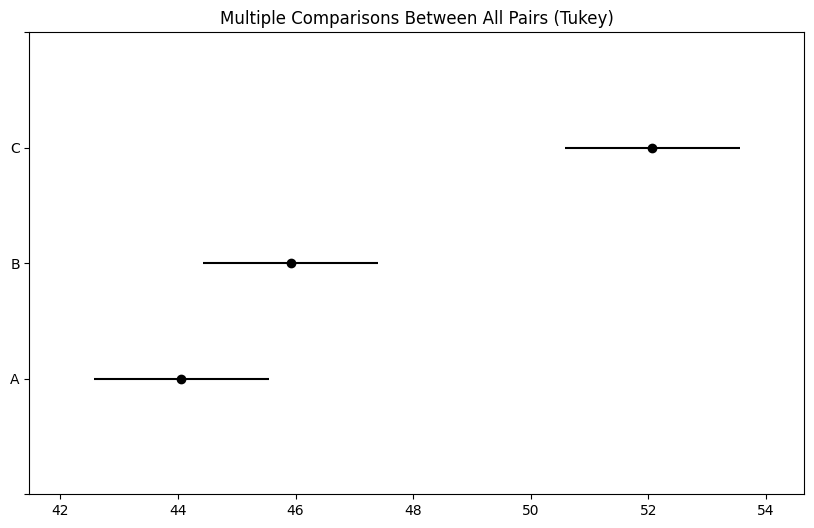

In [12]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
# Preparación de datos
datos_combinados = pd.DataFrame({'Valor': np.concatenate([grupo_A, grupo_B,
grupo_C]),
                                 'Grupo': ['A']*30 + ['B']*30 + ['C']*30})
tukey = pairwise_tukeyhsd(endog=datos_combinados['Valor'],
                          groups=datos_combinados['Grupo'],
                          alpha=0.05)
print(tukey)
tukey.plot_simultaneous()
plt.show()

### **Enlace de consulta a la IA**:
https://share.gemini.google/uJGRaGa6hzAs


#**Preguntas de Control**


## **1. Utilice scipy.stats.levene para verificar la igualdad de varianzas.**



La prueba de Levene se realizó en la Tarea 2 al hacer el análisis de la ejecución del ANOVA.

* Resultados de la prueba de Levene:
Estadístico de Levene: 1.9822
Valor-p: 0.1627


* Interpretación:
Dado que el valor-p (0.1627) es mayor que el nivel de significancia (por ejemplo, 0.05),
no se rechaza la hipótesis nula de que las varianzas son iguales entre los grupos.
Por lo tanto, el supuesto de homocedasticidad se cumple para este análisis.

## **2. Discusión: Si el supuesto de homocedasticidad se viola, ¿qué alternativa no paramétrica (ej. Kruskal-Wallis) sería adecuada?**

El supuesto de **homocedasticidad** significa: igualdad de varianzas, cuando este se viola, dependiendo de si se busca una alternativa no paramétrica (basada en rangos) o una modificación paramétrica robusta, las mejores opciones son:

### 1. Pruebas No Paramétricas (Basadas en Rangos)

Estas pruebas no asumen normalidad, si la varianza difiere drásticamente entre grupos, su interpretación cambia de "comparar medianas" a evaluar la dominancia estocástica.

##### A. Para comparar 3 o más grupos independientes:

* **Prueba de Kruskal-Wallis con Rangos Robusto / Ajuste de Brunner-Munzel (Multigrupo):** Es el equivalente no paramétrico directa al ANOVA de un factor. Si las varianzas son distintas pero la forma de la distribución es similar, es muy efectiva.

##### B. Para comparar 2 grupos independientes:

* **Prueba de Brunner-Munzel:** No requiere la hipótesis de varianzas ni formas iguales entre los dos grupos.

### 2. Alternativas Paramétricas Robustas (Suelen ser mejores que la vía no paramétrica)

Muchas veces, cuando falla únicamente la homocedasticidad pero los datos se pueden aproximar aceptablemente bien o se busca comparar directamente las medias, lo ideal es recurrir a pruebas paramétricas adaptadas que ajusten los grados de libertad:

###### A. Para 3 o más grupos (Sustituto directo de `f_oneway` / ANOVA):

* **ANOVA de Welch (`Welch's ANOVA`):** Solución cuando las varianzas son desiguales. No asume varianzas iguales y ajusta el estadístico $F$ mediante los grados de libertad de Welch-Satterthwaite.

##### B. Para 2 grupos:

* **Prueba $t$ de Welch:** Ajusta la prueba $t$ tradicional desestimando la varianza conjunta.

#**Conclusiones**

* Se logró generar reportes estadísticos que contrasten medias de tres o más grupos utilizando ANOVA, aplicando los conocimientos al DataSet regional en el cual el grupo está trabajando.

* Se pudo interpretar correctamente los valores-p para determinar si existen diferencias estadísticamente significativas entre los grupos analizados usando herramientas de python además de los conocimientos teóricos aprendidos en clase.

* Se logró validar los supuestos de normalidad y homocedasticidad (primeramente conociendo estos conceptos) requeridos para la validez del análisis de varianza.